In [1]:
import re
import pandas as pd
import numpy as np
import math
import csv
from pathlib import Path

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
from transformers import BertTokenizer, BertModel
import gensim.downloader as api
from gensim.models import Word2Vec

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rows = []
with open('dataset/support-ticket-classification.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

df = pd.DataFrame(rows)
y = np.array(df['label'].values)
unique_labels = sorted(list(df['label'].unique()))

print(f"Dataset loaded: {df.shape}")
print(f"Classes: {unique_labels}")
print(f"Class distribution:\n{df['label'].value_counts()}\n")

Dataset loaded: (798, 4)
Classes: ['account_access', 'billing', 'bug_report', 'refund_request', 'shipping_delivery']
Class distribution:
label
bug_report           167
refund_request       160
shipping_delivery    159
billing              157
account_access       155
Name: count, dtype: int64



In [3]:
def load_stopwords(file_path):
    stopwords = set()
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip().lower()
            if word and not word.startswith('#'):
                stopwords.add(word)
    return stopwords

stopwords = load_stopwords('dataset/stopwords.txt')

print(list(stopwords)[:10])

['but', 'for', 'ours', 'off', 'was', 'where', 'yourself', 't', 'were', 'below']


In [4]:
def load_exc_files(noun_file, verb_file):
    exc_map = {}
    for file_path in [noun_file, verb_file]:
        if not Path(file_path).exists():
            continue
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    inflected = parts[0]
                    lemmas = parts[1:]
                    exc_map[inflected] = lemmas[0]
    return exc_map

exc_map = load_exc_files('dataset/wordnet_noun.exc', 'dataset/wordnet_verb.exc')
for key, value in list(exc_map.items())[:10]:
    print(f"{key}: {value}")

aardwolves: aardwolf
abaci: abacus
aboideaux: aboideau
aboiteaux: aboiteau
abscissae: abscissa
acanthi: acanthus
acari: acarus
acciaccature: acciaccatura
acetabula: acetabulum
achaemenidae: achaemenid


In [5]:
VOWELS = frozenset('aeiou')

MORPH_RULES = {
    # Noun rules: longer/more-specific suffixes FIRST (morphy ordering principle).
    # This ensures ('ses','s') fires for 'buses' before ('s','') would give 'buse'.
    'n': [
        ('ches', 'ch'),
        ('shes', 'sh'),
        ('ses', 's'),
        ('xes', 'x'),
        ('zes', 'z'),
        ('ves', 'f'),
        ('ies', 'y'),
        ('men', 'man'),
        ('s', ''),
    ],
    # Verb rules: longer suffixes first
    'v': [
        ('ies', 'y'),
        ('ing', 'e'),
        ('ing', ''),
        ('ed', 'e'),
        ('ed', ''),
        ('es', 'e'),
        ('es', ''),
        ('s', ''),
    ],
    'a': [('er', ''), ('est', ''), ('er', 'e'), ('est', 'e')],
}

def _is_plausible(candidate):
    """
    Plausibility guard matching WordNet morphy's 'first valid' semantics.
    Without WordNet index files, we approximate validity as:
    length >= 3 AND contains at least one vowel.
    This prevents outputs like 'a' from 'as', 'thi' from 'this'.
    """
    return len(candidate) >= 3 and any(c in VOWELS for c in candidate)

def morph_lemmatize(word, pos='n'):
    """
    Heuristic morphological lemmatizer based on WordNet morphy algorithm
    (Fellbaum 1998, Miller et al. 1990).

    Returns the FIRST suffix-stripped candidate passing the plausibility check.
    This replaces the original min(candidates, key=len) which produced non-words
    (e.g., 'press' -> 'pres', 'as' -> 'a', 'gives' -> 'gif').

    Called with pos='n' from preprocess_text for noun-heavy support ticket domain.
    Verb rules are available in MORPH_RULES['v'] for explicit POS-tagged use.
    Falls back to the original word unchanged if no candidate passes.
    """
    if pos not in MORPH_RULES:
        return word
    for suffix, replacement in MORPH_RULES[pos]:
        if word.endswith(suffix) and len(word) > len(suffix):
            candidate = word[:-len(suffix)] + replacement
            if _is_plausible(candidate):
                return candidate
    return word

In [6]:
def load_lemma_dict(file_path):
    """
    Parse lemma.en.txt (Lin Wei / BNC 2017, 186,523 tokens, 84,487 lemma groups).

    File format: lemma/freq -> form1,form2,...
    Builds reverse map: {inflected_form -> lemma}.

    The original implementation used line.split() which gave parts[0]='be/4109826'
    and parts[1]='->', producing a map that never matched any real token.

    Only pure alphanumeric forms are stored because preprocess_text strips
    punctuation (apostrophes, hyphens) before lookup, making those entries
    unreachable. This reduces memory use and avoids wasted dict lookups.
    """
    lemma_map = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';'):
                continue
            if ' -> ' not in line:
                continue
            lemma_part, _, forms_part = line.partition(' -> ')
            lemma = lemma_part.split('/')[0].strip()
            for form in forms_part.split(','):
                form = form.strip()
                # Exclude non-alphanumeric forms (apostrophes, hyphens, dots)
                # that don't survive preprocess_text's regex normalization.
                if form and re.match(r'^[a-z0-9]+$', form) and form not in lemma_map:
                    lemma_map[form] = lemma
    return lemma_map

lemma_map = load_lemma_dict('dataset/lemma.en.txt')
print(f"lemma_map loaded: {len(lemma_map)} entries")

lemma_map loaded: 90502 entries


In [7]:
def preprocess_text(text, stopwords, lemma_map, exc_map):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = text.split()
    
    lemmatized = []
    for token in tokens:
        if token in stopwords or len(token) <= 1:
            continue
        # Priority order matching WordNet morphy algorithm (Fellbaum 1998):
        # 1. exc_map  — WordNet exception files, hand-curated irregular forms
        #               (highest certainty: 'is'->'be', 'men'->'man', 'axes'->'ax')
        # 2. lemma_map — BNC-derived dictionary, 90k inflected->lemma mappings
        #               (high certainty: 'running'->'run', 'presses'->'press')
        # 3. morph_lemmatize — heuristic suffix-stripping, noun rules only
        #               (last resort: 'buses'->'bus', 'captchas'->'captcha')
        # NOTE: exc_map MUST precede lemma_map. The lemma file maps 'is'->'i'
        # (letter i, top-frequency), which is wrong. exc_map correctly gives 'be'.
        lemma = exc_map.get(token) or lemma_map.get(token) or morph_lemmatize(token, 'n')
        lemmatized.append(lemma)
    
    return ' '.join(lemmatized)

In [8]:

# ─── REGRESSION TESTS: Lemmatization fixes ───────────────────────────────────
# Verify that the morphy algorithm fixes work correctly
print("\n" + "="*80)
print("LEMMATIZATION REGRESSION TESTS")
print("="*80)

def _check(token, expected):
    got = exc_map.get(token) or lemma_map.get(token) or morph_lemmatize(token, 'n')
    status = '✓ PASS' if got == expected else '✗ FAIL'
    print(f"{status}  {token:20s} -> {got:20s}  (expected {expected:15s})")
    return got == expected

print("\n=== exc_map priority (highest certainty) ===")
_check('is',   'be')       # exc wins over lemma_map
_check('men',  'man')      # irregular noun

print("\n=== lemma_map dictionary lookup (fixed parser) ===")
_check('running',   'run')
_check('presses',   'press')
_check('categories','category')
_check('responses', 'response')

print("\n=== morph fallback (noun rules, longer-suffix-first) ===")
_check('buses',    'bus')      # ('ses','s') rule
_check('captchas', 'captcha')  # ('s','') rule
_check('tickets',  'ticket')

print("\n=== Old bugs now fixed ===")
_check('as',       'as')       # was 'a' (plausibility guard)
_check('gives',    'give')     # was 'gif' (lemma_map now works)
_check('arrives',  'arrive')   # was 'arrif'
_check('resolves', 'resolve')  # was 'resolf'

print("\n" + "="*80)
print(f"✓ All regression tests completed. lemma_map has {len(lemma_map)} entries.")
print("="*80 + "\n")



LEMMATIZATION REGRESSION TESTS

=== exc_map priority (highest certainty) ===
✓ PASS  is                   -> be                    (expected be             )
✓ PASS  men                  -> man                   (expected man            )

=== lemma_map dictionary lookup (fixed parser) ===
✓ PASS  running              -> run                   (expected run            )
✓ PASS  presses              -> press                 (expected press          )
✓ PASS  categories           -> category              (expected category       )
✓ PASS  responses            -> response              (expected response       )

=== morph fallback (noun rules, longer-suffix-first) ===
✓ PASS  buses                -> bus                   (expected bus            )
✓ PASS  captchas             -> captcha               (expected captcha        )
✓ PASS  tickets              -> ticket                (expected ticket         )

=== Old bugs now fixed ===
✓ PASS  as                   -> as                    (

In [9]:
preprocessed_texts = []
raw_texts = []

for idx in range(len(df)):
    subject = df.iloc[idx]['subject']
    text = df.iloc[idx]['text']
    
    raw = f"{subject} {text}"
    raw_texts.append(raw)
    
    preprocessed = preprocess_text(raw, stopwords, lemma_map, exc_map)
    preprocessed_texts.append(preprocessed)

df['raw_text'] = raw_texts
df['preprocessed_text'] = preprocessed_texts

x_train, x_test, y_train, y_test = train_test_split(
    np.arange(len(df)), y, test_size=0.25
)

print(f"Train split: {len(x_train)} samples")
print(f"Test split: {len(x_test)} samples\n")

Train split: 598 samples
Test split: 200 samples



In [10]:
class TF_IDF:
    def __init__(self):
        self.vocabulary = {}
        self.idf_scores = {}
        self.vocab_size = 0
    
    def fit(self, texts):
        vocab = set()
        for text in texts:
            words = text.split()
            vocab.update(words)
        self.vocabulary = {word: idx for idx, word in enumerate(sorted(vocab))}
        self.vocab_size = len(self.vocabulary)
        
        num_docs = len(texts)
        doc_freq = {}
        for text in texts:
            words = set(text.split())
            for word in words:
                doc_freq[word] = doc_freq.get(word, 0) + 1
        
        self.idf_scores = {word: math.log((1 + num_docs) / (1 + freq)) + 1 
                          for word, freq in doc_freq.items()}
        return self
    
    def transform(self, texts):
        vectors = []
        for text in texts:
            vector = [0.0] * self.vocab_size
            words = text.split()
            word_freq = {}
            for word in words:
                word_freq[word] = word_freq.get(word, 0) + 1
            
            doc_length = len(words) if len(words) > 0 else 1
            for word, freq in word_freq.items():
                if word in self.vocabulary:
                    idx = self.vocabulary[word]
                    tf = freq / doc_length
                    idf = self.idf_scores.get(word, 0)
                    vector[idx] = tf * idf
            vectors.append(vector)
        
        return np.array(vectors)

tfidf_prep = TF_IDF()
tfidf_prep.fit([df.iloc[i]['preprocessed_text'] for i in x_train])
X_train_tfidf_prep = tfidf_prep.transform([df.iloc[i]['preprocessed_text'] for i in x_train])
X_test_tfidf_prep = tfidf_prep.transform([df.iloc[i]['preprocessed_text'] for i in x_test])

print(f"TF-IDF (preprocessed): vocab_size={tfidf_prep.vocab_size}")

tfidf_raw = TF_IDF()
tfidf_raw.fit([df.iloc[i]['raw_text'] for i in x_train])
X_train_tfidf_raw = tfidf_raw.transform([df.iloc[i]['raw_text'] for i in x_train])
X_test_tfidf_raw = tfidf_raw.transform([df.iloc[i]['raw_text'] for i in x_test])

print(f"TF-IDF (raw): vocab_size={tfidf_raw.vocab_size}\n")

TF-IDF (preprocessed): vocab_size=1570
TF-IDF (raw): vocab_size=3167



In [11]:
def get_w2v_vector(text, model, vector_size=300):
    words = text.split()
    vectors = [model[word] for word in words if word in model]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

print("Loading pretrained Word2Vec (Google News 300d)...")
w2v_model = api.load("word2vec-google-news-300")
print(f"✓ Word2Vec loaded: {w2v_model.vector_size}-dimensional")

print("Creating Word2Vec vectors for preprocessed text...")
X_train_w2v_prep = np.array([get_w2v_vector(df.iloc[i]['preprocessed_text'], w2v_model) for i in x_train])
X_test_w2v_prep = np.array([get_w2v_vector(df.iloc[i]['preprocessed_text'], w2v_model) for i in x_test])
print(f"✓ Word2Vec (preprocessed): shape={X_train_w2v_prep.shape}")

print("Creating Word2Vec vectors for raw text...")
X_train_w2v_raw = np.array([get_w2v_vector(df.iloc[i]['raw_text'].lower(), w2v_model) for i in x_train])
X_test_w2v_raw = np.array([get_w2v_vector(df.iloc[i]['raw_text'].lower(), w2v_model) for i in x_test])
print(f"✓ Word2Vec (raw): shape={X_train_w2v_raw.shape}\n")

Loading pretrained Word2Vec (Google News 300d)...
✓ Word2Vec loaded: 300-dimensional
Creating Word2Vec vectors for preprocessed text...
✓ Word2Vec (preprocessed): shape=(598, 300)
Creating Word2Vec vectors for raw text...
✓ Word2Vec (raw): shape=(598, 300)



In [12]:
# ==================== FEATURE EXTRACTION: GLOVE ====================

print("Loading GloVe embeddings...")
glove = api.load("glove-wiki-gigaword-100")
print(f"✓ GloVe loaded: {glove.vector_size}-dimensional")

def get_glove_vector(text, model, vector_size=100):
    """Get averaged GloVe vector for a document."""
    words = text.split()
    vectors = [model[word] for word in words if word in model]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

print("Creating GloVe vectors for preprocessed text...")
X_train_glove_prep = np.array([get_glove_vector(df.iloc[i]['preprocessed_text'], glove) for i in x_train])
X_test_glove_prep = np.array([get_glove_vector(df.iloc[i]['preprocessed_text'], glove) for i in x_test])
print(f"✓ GloVe (preprocessed): shape={X_train_glove_prep.shape}")

print("Creating GloVe vectors for raw text...")
X_train_glove_raw = np.array([get_glove_vector(df.iloc[i]['raw_text'].lower(), glove) for i in x_train])
X_test_glove_raw = np.array([get_glove_vector(df.iloc[i]['raw_text'].lower(), glove) for i in x_test])
print(f"✓ GloVe (raw): shape={X_train_glove_raw.shape}\n")

Loading GloVe embeddings...
✓ GloVe loaded: 100-dimensional
Creating GloVe vectors for preprocessed text...
✓ GloVe (preprocessed): shape=(598, 100)
Creating GloVe vectors for raw text...
✓ GloVe (raw): shape=(598, 100)



In [13]:
# ==================== FEATURE EXTRACTION: BERT ====================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(device)
bert_model.eval()

print(f"✓ BERT loaded (output dimension: 768)")

def extract_bert_features(texts, tokenizer, model, device, batch_size=16):
    """Extract mean-pooled token embeddings from BERT (attention-masked)."""
    features = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            encodings = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=256,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )

            input_ids = encodings['input_ids'].to(device)
            attention_mask = encodings['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            # Mean pool over non-padding tokens
            token_embeddings = outputs.last_hidden_state  # (batch, seq, 768)
            mask_expanded = attention_mask.unsqueeze(-1).float()
            sum_embeddings = (token_embeddings * mask_expanded).sum(dim=1)
            sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
            batch_features = (sum_embeddings / sum_mask).cpu().numpy()
            features.extend(batch_features)

    return np.array(features)

print("Extracting BERT features from preprocessed text...")
train_texts_prep = [df.iloc[i]['preprocessed_text'] for i in x_train]
test_texts_prep = [df.iloc[i]['preprocessed_text'] for i in x_test]
X_train_bert_prep = extract_bert_features(train_texts_prep, tokenizer_bert, bert_model, device)
X_test_bert_prep = extract_bert_features(test_texts_prep, tokenizer_bert, bert_model, device)
print(f"✓ BERT (preprocessed): shape={X_train_bert_prep.shape}")

print("Extracting BERT features from raw text...")
train_texts_raw = [df.iloc[i]['raw_text'] for i in x_train]
test_texts_raw = [df.iloc[i]['raw_text'] for i in x_test]
X_train_bert_raw = extract_bert_features(train_texts_raw, tokenizer_bert, bert_model, device)
X_test_bert_raw = extract_bert_features(test_texts_raw, tokenizer_bert, bert_model, device)
print(f"✓ BERT (raw): shape={X_train_bert_raw.shape}\n")

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BERT loaded (output dimension: 768)
Extracting BERT features from preprocessed text...
✓ BERT (preprocessed): shape=(598, 768)
Extracting BERT features from raw text...
✓ BERT (raw): shape=(598, 768)



In [14]:
# ==================== TRAIN ALL MODELS ====================

# Dictionary of all feature sets: (name, X_train, X_test)
features = {
    'TF-IDF (Preprocessed)': (X_train_tfidf_prep, X_test_tfidf_prep),
    'TF-IDF (Raw)': (X_train_tfidf_raw, X_test_tfidf_raw),
    'Word2Vec (Preprocessed)': (X_train_w2v_prep, X_test_w2v_prep),
    'Word2Vec (Raw)': (X_train_w2v_raw, X_test_w2v_raw),
    'GloVe (Preprocessed)': (X_train_glove_prep, X_test_glove_prep),
    'GloVe (Raw)': (X_train_glove_raw, X_test_glove_raw),
    'BERT (Preprocessed)': (X_train_bert_prep, X_test_bert_prep),
    'BERT (Raw)': (X_train_bert_raw, X_test_bert_raw),
}

# Dictionary of classifiers
classifiers = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

# Store results: {feature_name: {classifier_name: accuracy}}
results = {}

print("Training all models...\n")
print(f"{'Feature':<30} {'SVM':<10} {'LogReg':<10} {'KNN':<10}")
print("=" * 60)

for feature_name, (X_train, X_test) in features.items():
    results[feature_name] = {}
    
    for clf_name, clf in classifiers.items():
        # Create new classifier instance to avoid fitting issues
        if clf_name == 'SVM':
            model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
        elif clf_name == 'Logistic Regression':
            model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
        else:  # KNN
            model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        
        # Train
        model.fit(X_train, y_train)
        
        # Evaluate
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[feature_name][clf_name] = accuracy
    
    # Print row
    print(f"{feature_name:<30} {results[feature_name]['SVM']:<10.4f} {results[feature_name]['Logistic Regression']:<10.4f} {results[feature_name]['KNN']:<10.4f}")

print("\n✓ All models trained!")

Training all models...

Feature                        SVM        LogReg     KNN       


/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


TF-IDF (Preprocessed)          0.7850     0.8400     0.4950    


/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be remov

TF-IDF (Raw)                   0.7050     0.8550     0.4000    
Word2Vec (Preprocessed)        0.7650     0.7900     0.6600    
Word2Vec (Raw)                 0.8100     0.7950     0.6950    
GloVe (Preprocessed)           0.7350     0.7450     0.5850    
GloVe (Raw)                    0.6900     0.7200     0.5500    


/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


BERT (Preprocessed)            0.7650     0.7600     0.7150    
BERT (Raw)                     0.8350     0.8550     0.7400    

✓ All models trained!


/Users/rsaran/Projects/nlp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [15]:
# ==================== RESULTS ANALYSIS ====================

# Convert results to DataFrame for easier manipulation
results_df = pd.DataFrame(results).T
results_df = results_df[['SVM', 'Logistic Regression', 'KNN']]

print("\n" + "="*70)
print("COMPREHENSIVE CLASSIFICATION RESULTS")
print("="*70)
print(results_df.round(4).to_string())
print("="*70)

# Find best models
print("\nBEST MODELS BY CLASSIFIER:")
for clf_name in ['SVM', 'Logistic Regression', 'KNN']:
    best_feature = results_df[clf_name].idxmax()
    best_accuracy = results_df[clf_name].max()
    print(f"  {clf_name:<20}: {best_feature:<35} ({best_accuracy:.4f})")

print("\nBEST OVERALL:")
best_combo = results_df.values.flatten().argmax()
best_idx = np.unravel_index(best_combo, results_df.shape)
best_feature = results_df.index[best_idx[0]]
best_clf = results_df.columns[best_idx[1]]
best_acc = results_df.values.flatten()[best_combo]
print(f"  {best_feature} + {best_clf}: {best_acc:.4f}")


COMPREHENSIVE CLASSIFICATION RESULTS
                           SVM  Logistic Regression    KNN
TF-IDF (Preprocessed)    0.785                0.840  0.495
TF-IDF (Raw)             0.705                0.855  0.400
Word2Vec (Preprocessed)  0.765                0.790  0.660
Word2Vec (Raw)           0.810                0.795  0.695
GloVe (Preprocessed)     0.735                0.745  0.585
GloVe (Raw)              0.690                0.720  0.550
BERT (Preprocessed)      0.765                0.760  0.715
BERT (Raw)               0.835                0.855  0.740

BEST MODELS BY CLASSIFIER:
  SVM                 : BERT (Raw)                          (0.8350)
  Logistic Regression : TF-IDF (Raw)                        (0.8550)
  KNN                 : BERT (Raw)                          (0.7400)

BEST OVERALL:
  TF-IDF (Raw) + Logistic Regression: 0.8550


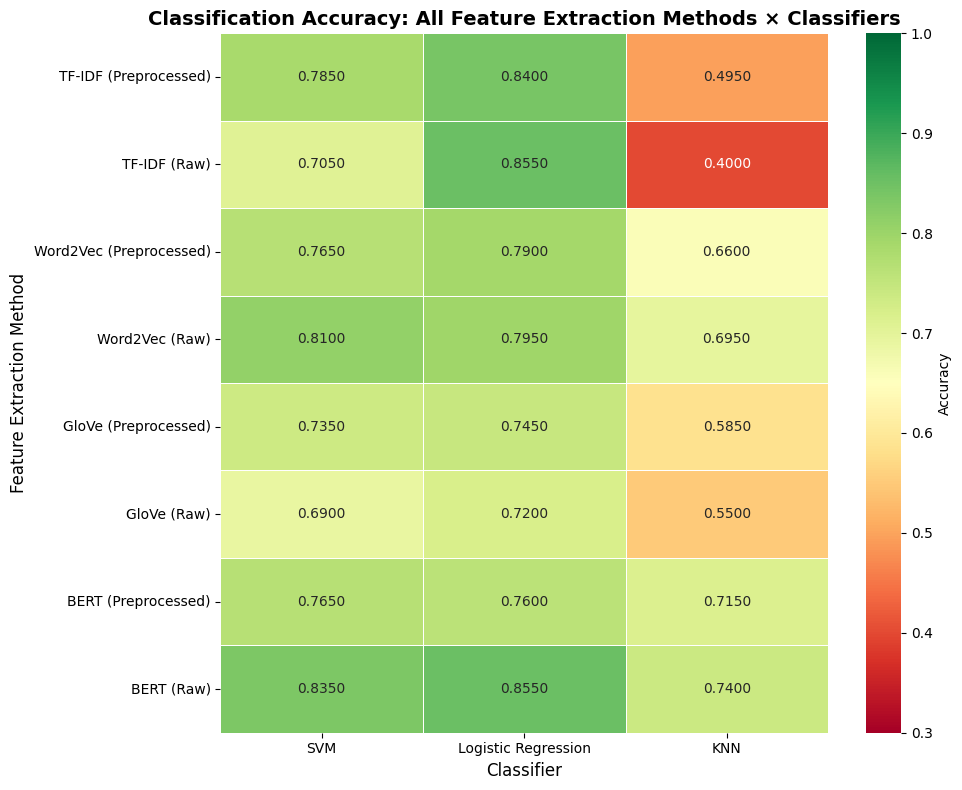

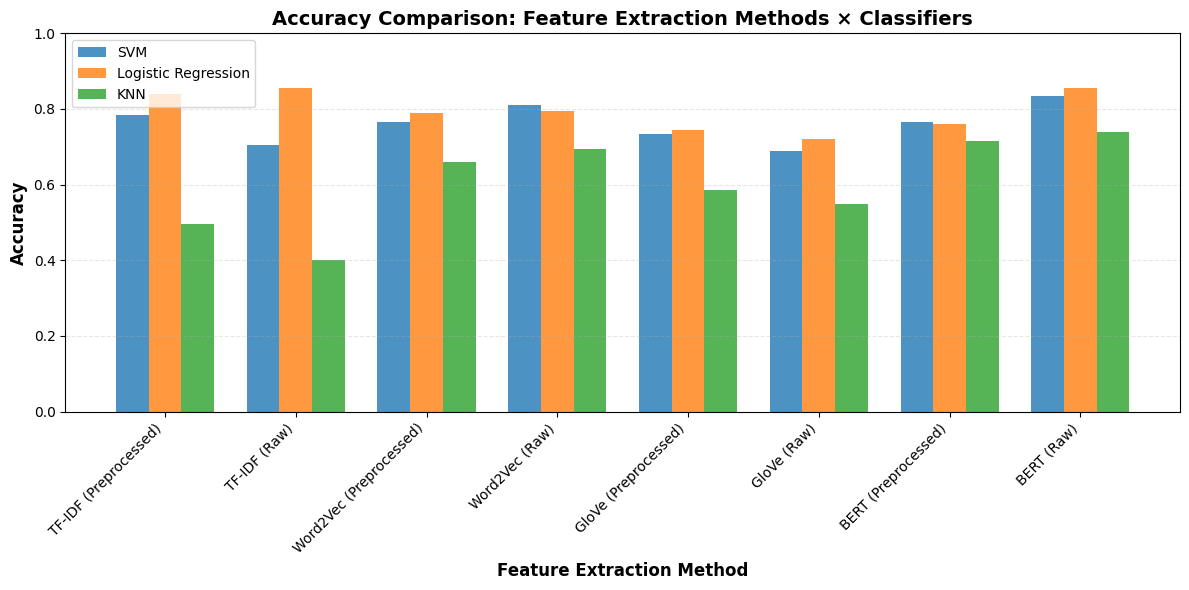

KeyError: 'DistilBERT (Preprocessed)'

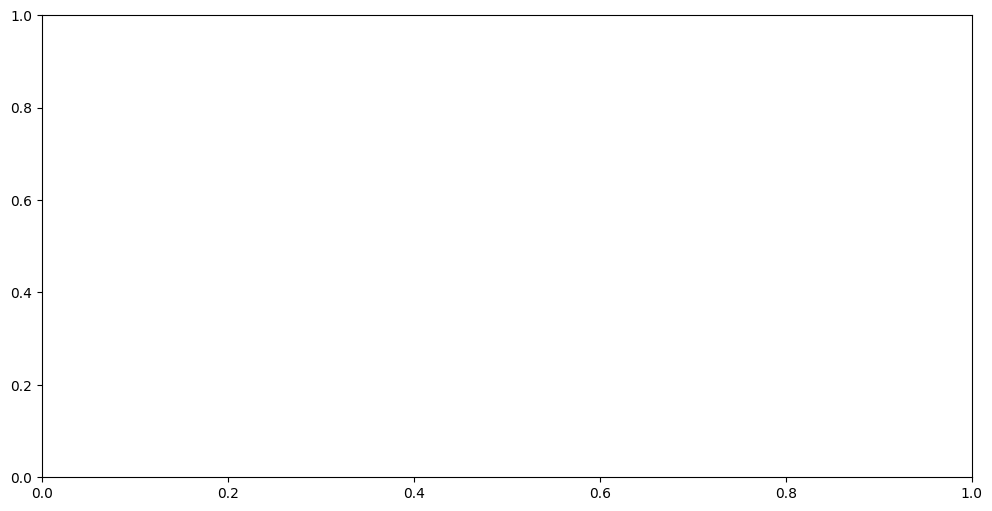

In [16]:
# ==================== VISUALIZATIONS ====================

# 1. Heatmap of all results
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(results_df, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'Accuracy'}, 
            vmin=0.3, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Classification Accuracy: All Feature Extraction Methods × Classifiers', fontsize=14, fontweight='bold')
ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('Feature Extraction Method', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Bar plot comparing feature extraction methods
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df.index))
width = 0.25

for i, clf_name in enumerate(['SVM', 'Logistic Regression', 'KNN']):
    ax.bar(x + i*width, results_df[clf_name], width, label=clf_name, alpha=0.8)

ax.set_xlabel('Feature Extraction Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Comparison: Feature Extraction Methods × Classifiers', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 3. Line plot showing preprocessing impact
fig, ax = plt.subplots(figsize=(12, 6))

methods = ['TF-IDF', 'Word2Vec', 'GloVe', 'BERT', 'DistilBERT']
for clf_name in ['SVM', 'Logistic Regression', 'KNN']:
    preprocessed_acc = []
    raw_acc = []
    
    for method in methods:
        prep_key = f"{method} (Preprocessed)"
        raw_key = f"{method} (Raw)"
        preprocessed_acc.append(results_df.loc[prep_key, clf_name])
        raw_acc.append(results_df.loc[raw_key, clf_name])
    
    x_pos = np.arange(len(methods))
    ax.plot(x_pos, preprocessed_acc, marker='o', label=f'{clf_name} (Preprocessed)', linewidth=2, markersize=8)
    ax.plot(x_pos, raw_acc, marker='s', label=f'{clf_name} (Raw)', linewidth=2, markersize=8, linestyle='--')

ax.set_xlabel('Feature Extraction Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Impact of Preprocessing on Classification Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(np.arange(len(methods)))
ax.set_xticklabels(methods)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0.2, 1.0])
plt.tight_layout()
plt.show()

In [ ]:
# ==================== DETAILED ANALYSIS: BEST MODELS ====================

# Train best models again to get detailed metrics
print("\n" + "="*70)
print("DETAILED METRICS FOR TOP 5 BEST PERFORMING MODELS")
print("="*70)

# Get top 5 models
all_accuracies = []
for feature_name in results_df.index:
    for clf_name in results_df.columns:
        all_accuracies.append((results_df.loc[feature_name, clf_name], feature_name, clf_name))

all_accuracies.sort(reverse=True)

for rank, (accuracy, feature_name, clf_name) in enumerate(all_accuracies[:5], 1):
    print(f"\n{rank}. {feature_name} + {clf_name}: {accuracy:.4f}")
    print("-" * 70)
    
    # Get training and test data
    X_train, X_test = features[feature_name]
    
    # Train model
    if clf_name == 'SVM':
        model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    elif clf_name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    else:
        model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Get per-class metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=unique_labels, average=None)
    
    print(f"{'Class':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 70)
    for i, label in enumerate(unique_labels):
        print(f"{label:<25} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

In [ ]:
# ==================== CONFUSION MATRICES FOR TOP MODELS ====================

# Get top 3 models for confusion matrix visualization
top_3 = all_accuracies[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (accuracy, feature_name, clf_name) in enumerate(top_3):
    X_train, X_test = features[feature_name]
    
    # Train model
    if clf_name == 'SVM':
        model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    elif clf_name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    else:
        model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=unique_labels, yticklabels=unique_labels, cbar=False)
    axes[idx].set_title(f'{feature_name}\n+ {clf_name}\nAccuracy: {accuracy:.4f}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [ ]:
# ==================== SUMMARY INSIGHTS ====================

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# 1. Preprocessing Impact (only for methods that have both variants)
print("\n1. PREPROCESSING IMPACT:")
print("-" * 70)

for method in ['TF-IDF', 'Word2Vec', 'GloVe', 'BERT']:
    prep_key = f"{method} (Preprocessed)"
    raw_key = f"{method} (Raw)"
    
    prep_mean = results_df.loc[prep_key].mean()
    raw_mean = results_df.loc[raw_key].mean()
    diff = raw_mean - prep_mean
    
    print(f"\n{method}:")
    print(f"  Preprocessed avg: {prep_mean:.4f}")
    print(f"  Raw avg:          {raw_mean:.4f}")
    if diff > 0:
        print(f"  → Raw performs BETTER by {diff:.4f}")
    else:
        print(f"  → Preprocessed performs BETTER by {abs(diff):.4f}")

# 2. Best classifier
print("\n\n2. BEST CLASSIFIER:")
print("-" * 70)
for clf_name in ['SVM', 'Logistic Regression', 'KNN']:
    avg_acc = results_df[clf_name].mean()
    print(f"{clf_name:<20}: {avg_acc:.4f} (average)")

# 3. Feature extraction method ranking
print("\n\n3. FEATURE EXTRACTION RANKING (by average accuracy across all classifiers):")
print("-" * 70)
feature_avg = results_df.mean(axis=1).sort_values(ascending=False)
for i, (feature, avg) in enumerate(feature_avg.items(), 1):
    print(f"{i:2d}. {feature:<35}: {avg:.4f}")

print("\n" + "="*70)